# GAMs with Different Response Distributions

## Overview

GAMs are generalized additive models — the G in GAM means they support the same family of response distributions as GLMs, extended with smooth terms. Choosing the right family is exactly as important in a GAM as in a GLM.

| Family | Response Type | Link | Use Case |
|---|---|---|---|
| `gaussian` | Continuous, symmetric | identity | Default; environmental measurements, measurements on a continuous scale |
| `binomial` | Binary or proportion | logit | Presence/absence, survival, binary outcomes |
| `poisson` | Non-negative integer | log | Counts — always check overdispersion |
| `nb` (negative binomial) | Overdispersed count | log | Counts where variance > mean — the common ecological case |
| `Tweedie` | Non-negative continuous with exact zeros | log | Biomass, rainfall, insurance claims — continuous but with a spike at zero |
| `Gamma` | Positive continuous, right-skewed | log | Strictly positive: claim amounts, concentrations, waiting times |
| `ziP` | Zero-inflated count | log | Excess zeros AND count structure |
| `ocat` | Ordered categorical | — | Ordinal responses |

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Binomial GAM for species detection probability across an environmental gradient; NB GAM for invertebrate abundance with overdispersion; Tweedie GAM for biomass (many sites with zero biomass) |
| **Healthcare** | Binomial GAM for disease probability across age; Poisson/NB GAM for count of adverse events; Gamma GAM for continuous biomarker |
| **Finance** | Binomial GAM for default probability; Tweedie GAM for claim costs (many zero-cost policies) |
| **Insurance** | Tweedie GAM for pure premium (frequency × severity combined); NB GAM for claim count; Gamma GAM for claim severity |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(mgcv)
library(gratia)
library(DHARMa)

set.seed(42)
n <- 250

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'mgcv' was built under R version 4.4.3"
Loading required package: nlme


Attaching package: 'nlme'


The fo

---

## Gaussian GAM

The default — for continuous, approximately normally distributed responses. Equivalent to a standard additive model.


Family: gaussian 
Link function: identity 

Formula:
y ~ s(x)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.44441    0.08889    27.5   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
       edf Ref.df     F p-value    
s(x) 8.485  8.925 161.9  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.853   Deviance explained = 85.8%
-REML = 458.02  Scale est. = 1.9754    n = 250

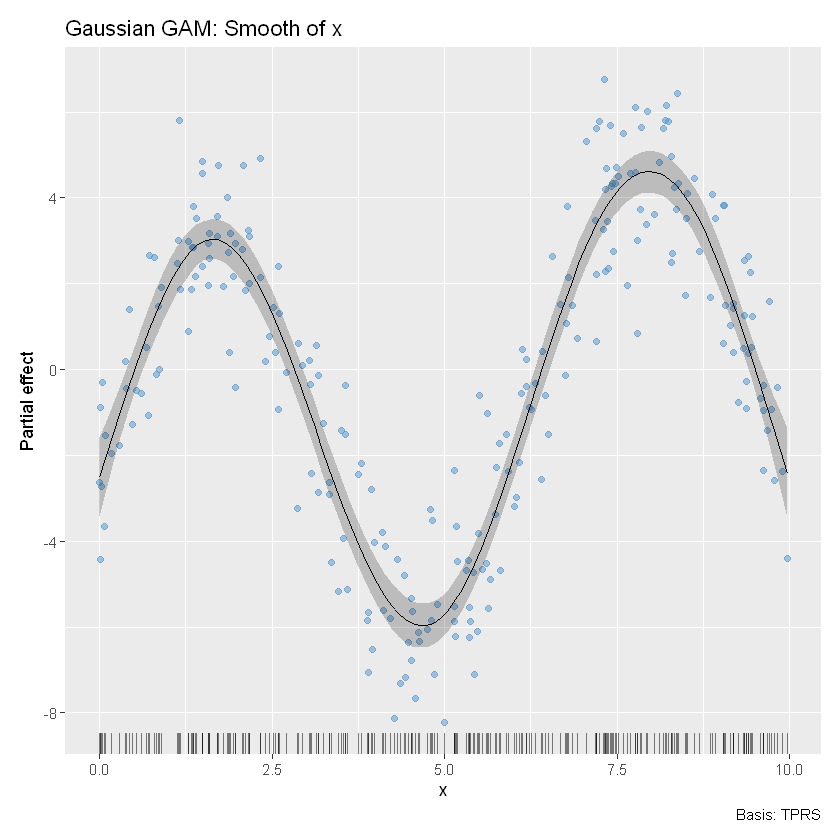

In [2]:
gauss_data <- tibble(
  x       = runif(n, 0, 10),
  y       = sin(x) * 5 + 0.3 * x + rnorm(n, 0, 1.5)
)

gam_gauss <- mgcv::gam(y ~ s(x), data = gauss_data, family = gaussian, method = "REML")
summary(gam_gauss)
gratia::draw(gam_gauss, residuals = TRUE) +
  labs(title = "Gaussian GAM: Smooth of x")

---

## Binomial GAM

For binary outcomes (0/1) or proportions. The smooth models the log-odds of the event — predictions are converted to probabilities with `type = "response"`.


Family: binomial 
Link function: logit 

Formula:
present ~ s(temp)

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)   0.3174     0.1354   2.345    0.019 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
          edf Ref.df Chi.sq  p-value    
s(temp) 2.951  3.664  24.43 6.37e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.106   Deviance explained = 8.69%
-REML =  160.6  Scale est. = 1         n = 250

Registered S3 methods overwritten by 'mgcViz':
  method       from   
  +.gg         ggplot2
  simulate.gam gratia 



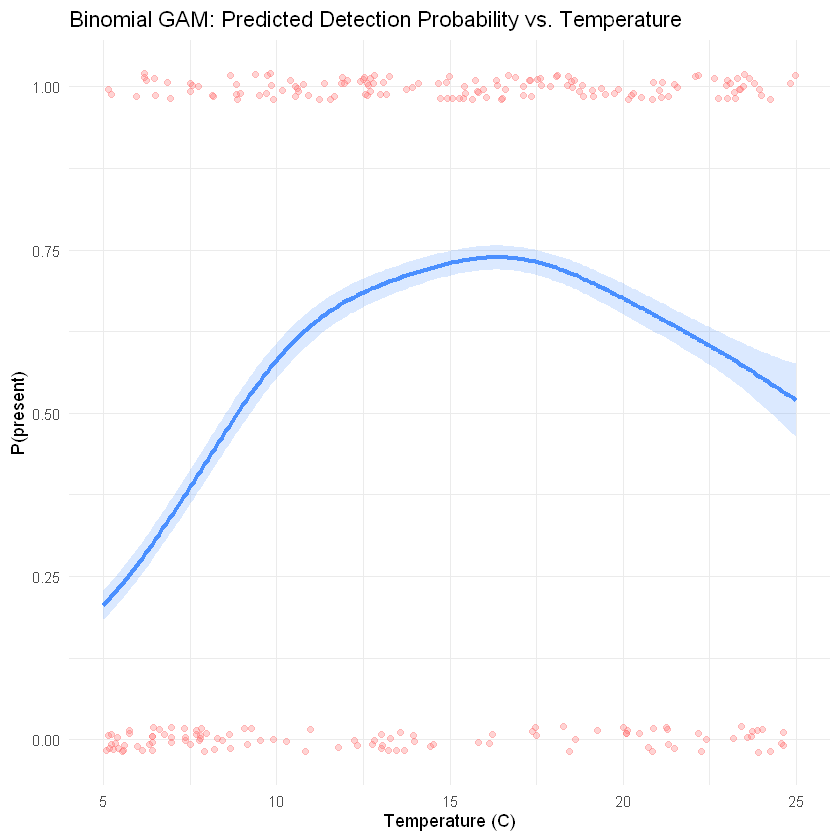

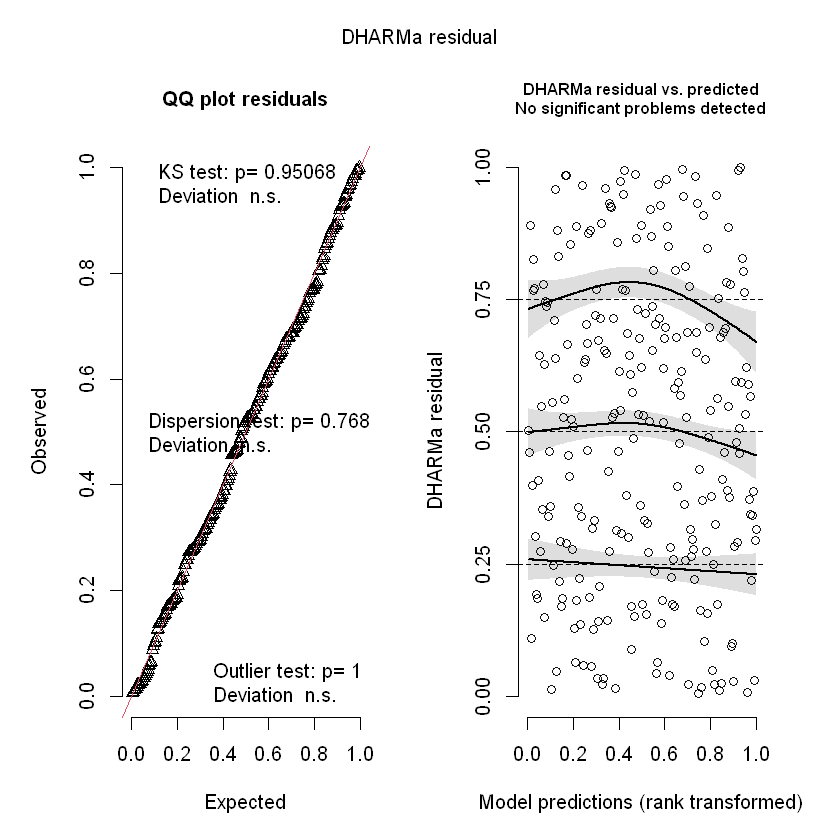

In [3]:
# ── Binary: species presence/absence across temperature gradient ───────────────
bin_data <- tibble(
  temp     = runif(n, 5, 25),
  log_odds = -3 + 0.5 * temp - 0.015 * temp^2,
  present  = rbinom(n, 1, plogis(log_odds))
) %>% select(-log_odds)

gam_bin <- mgcv::gam(
  present ~ s(temp),
  data   = bin_data,
  family = binomial(link = "logit"),
  method = "REML"
)
summary(gam_bin)

# ── Predicted probabilities ───────────────────────────────────────────────────
pred_bin <- tibble(
  temp = seq(5, 25, length.out = 200)
)
preds <- predict(gam_bin, newdata = pred_bin, type = "response", se.fit = TRUE)
pred_bin <- pred_bin %>%
  mutate(prob  = preds$fit,
         lower = plogis(qlogis(prob) - 1.96 * preds$se.fit),
         upper = plogis(qlogis(prob) + 1.96 * preds$se.fit))

ggplot() +
  geom_ribbon(data = pred_bin,
              aes(x = temp, ymin = lower, ymax = upper),
              alpha = 0.2, fill = "#4a8fff") +
  geom_line(data = pred_bin, aes(x = temp, y = prob),
            color = "#4a8fff", linewidth = 1.2) +
  geom_jitter(data = bin_data,
              aes(x = temp, y = present),
              height = 0.02, alpha = 0.3, color = "#ff6b6b") +
  labs(title = "Binomial GAM: Predicted Detection Probability vs. Temperature",
       x = "Temperature (C)", y = "P(present)") +
  theme_minimal()

# ── DHARMa check ──────────────────────────────────────────────────────────────
sim_bin <- DHARMa::simulateResiduals(gam_bin, n = 500)
plot(sim_bin)

---

## Negative Binomial GAM

For overdispersed count data. `mgcv` fits the NB dispersion parameter automatically alongside the smooth.


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 13.685, p-value < 2.2e-16
alternative hypothesis: two.sided



Family: Negative Binomial(1.778) 
Link function: log 

Formula:
count ~ s(pH)

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.85796    0.05032   56.79   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
        edf Ref.df Chi.sq p-value    
s(pH) 4.408  5.409  149.3  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.259   Deviance explained = 33.2%
-REML = 965.72  Scale est. = 1         n = 250

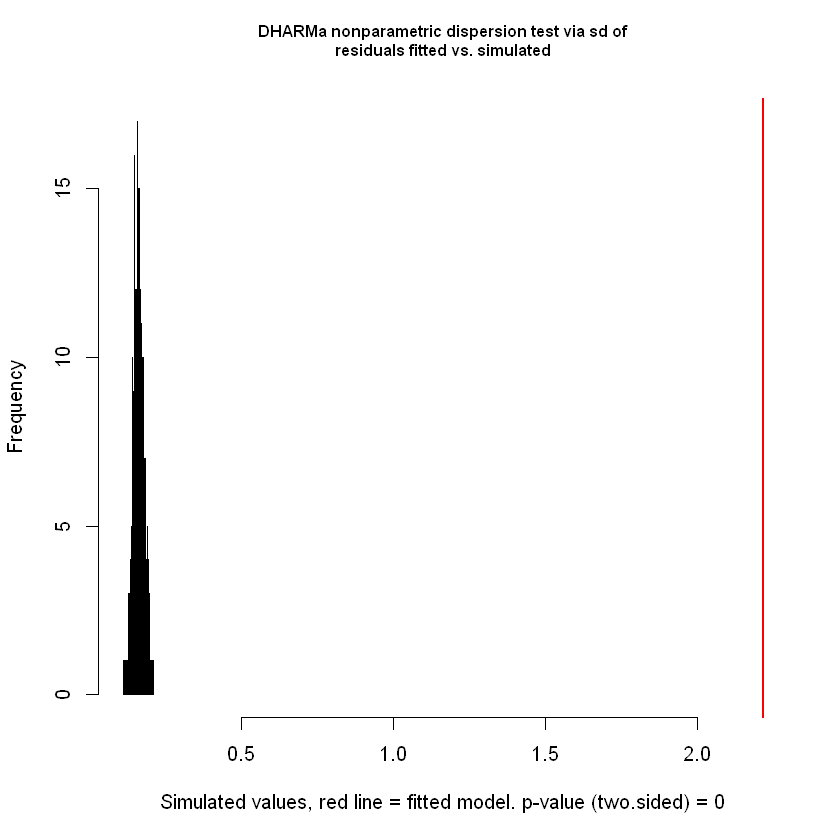

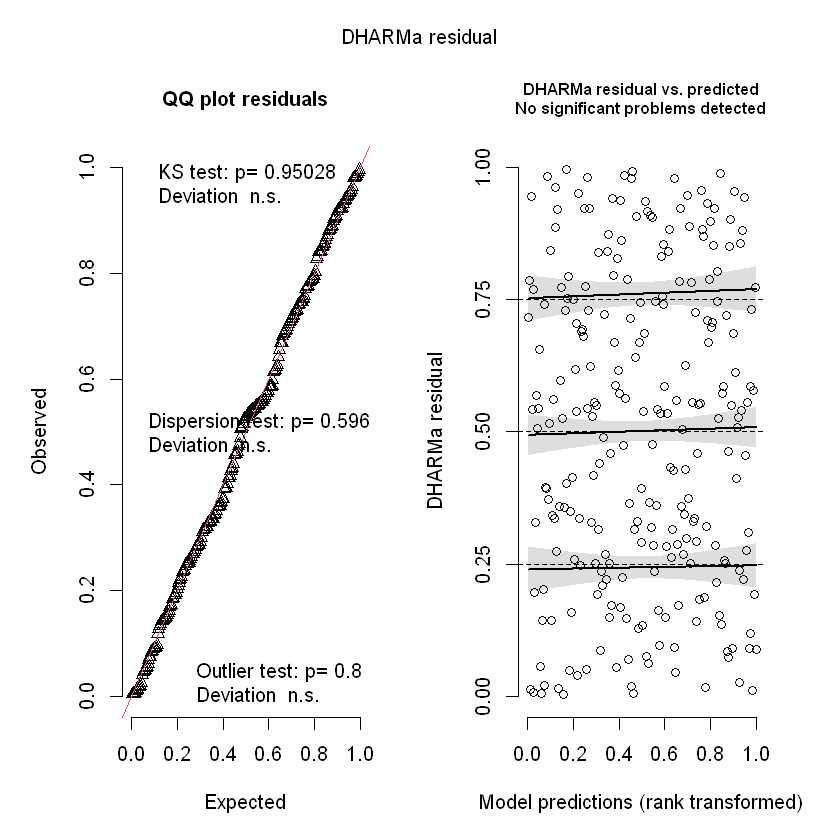


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.90188, p-value = 0.596
alternative hypothesis: two.sided


,df,AIC
,<dbl>,<dbl>
gam_pois,8.951659,3840.847
gam_nb,6.627127,1924.797


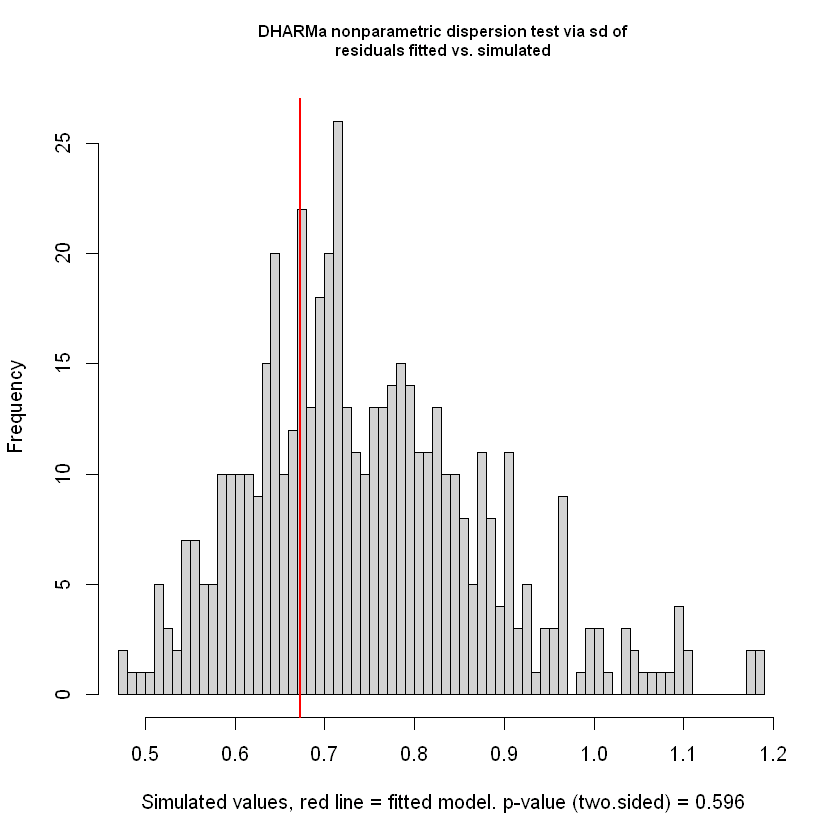

In [4]:
# ── Overdispersed count: invertebrate abundance ───────────────────────────────
nb_data <- tibble(
  pH    = runif(n, 6, 9),
  mu    = exp(2 + 1.5 * sin(pH - 6) - 0.2 * (pH - 7.5)^2),
  count = MASS::rnegbin(n, mu = mu, theta = 2)
) %>% select(-mu)

# ── Fit Poisson first, check overdispersion ───────────────────────────────────
gam_pois <- mgcv::gam(count ~ s(pH), data = nb_data,
                       family = poisson, method = "REML")
sim_pois <- DHARMa::simulateResiduals(gam_pois, n = 500)
DHARMa::testDispersion(sim_pois)
# p < 0.05: overdispersion → use negative binomial

# ── Fit NB GAM ────────────────────────────────────────────────────────────────
# nb() family in mgcv estimates theta automatically
gam_nb <- mgcv::gam(count ~ s(pH), data = nb_data,
                     family = mgcv::nb(), method = "REML")
summary(gam_nb)
# Estimated theta (dispersion) shown in summary

# ── DHARMa check on NB model ─────────────────────────────────────────────────
sim_nb <- DHARMa::simulateResiduals(gam_nb, n = 500)
plot(sim_nb)
DHARMa::testDispersion(sim_nb)   # should be non-significant now

# ── Compare AIC: Poisson vs. NB ───────────────────────────────────────────────
AIC(gam_pois, gam_nb)

---

## Tweedie GAM

The Tweedie family handles **non-negative continuous data with a point mass at zero** — a spike of exact zeros combined with a continuous positive distribution. This is common for biomass, precipitation, and insurance pure premium (many policies with zero claims, continuous distribution for those who claim).

The Tweedie power parameter p controls the distribution shape: p=1 is Poisson, p=2 is Gamma, 1<p<2 is compound Poisson-Gamma (the useful range for zero-inflated continuous data).

Zero proportion: 14.8%



Family: Tweedie(p=1.477) 
Link function: log 

Formula:
biomass ~ s(depth)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.3254     0.0631      21   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
           edf Ref.df    F p-value    
s(depth) 4.315  5.322 16.5  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.217   Deviance explained = 23.9%
-REML = 638.83  Scale est. = 1.8857    n = 250

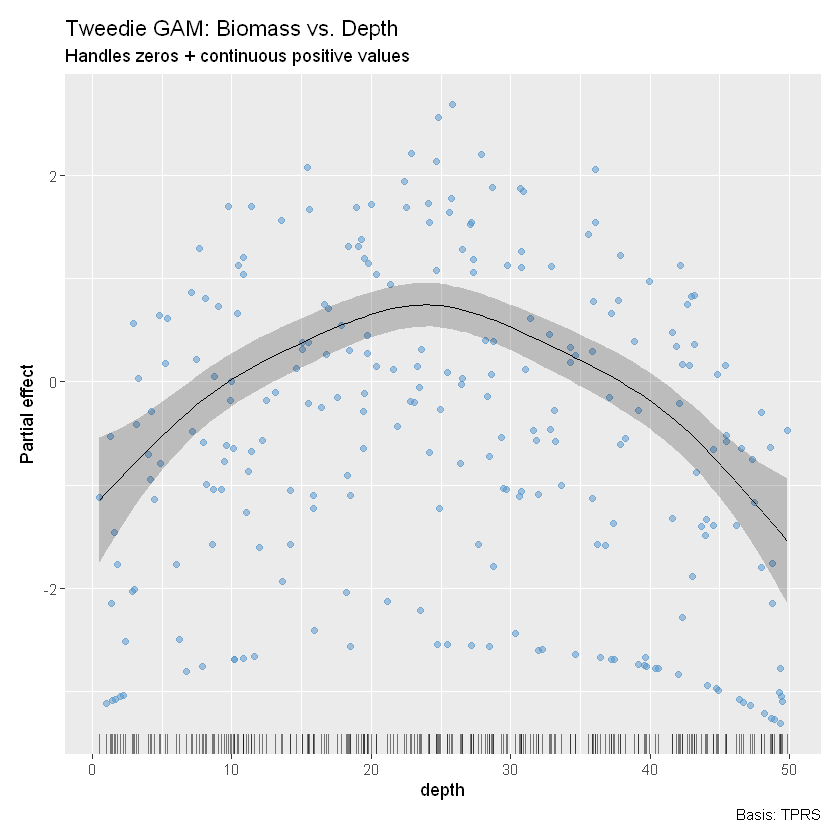

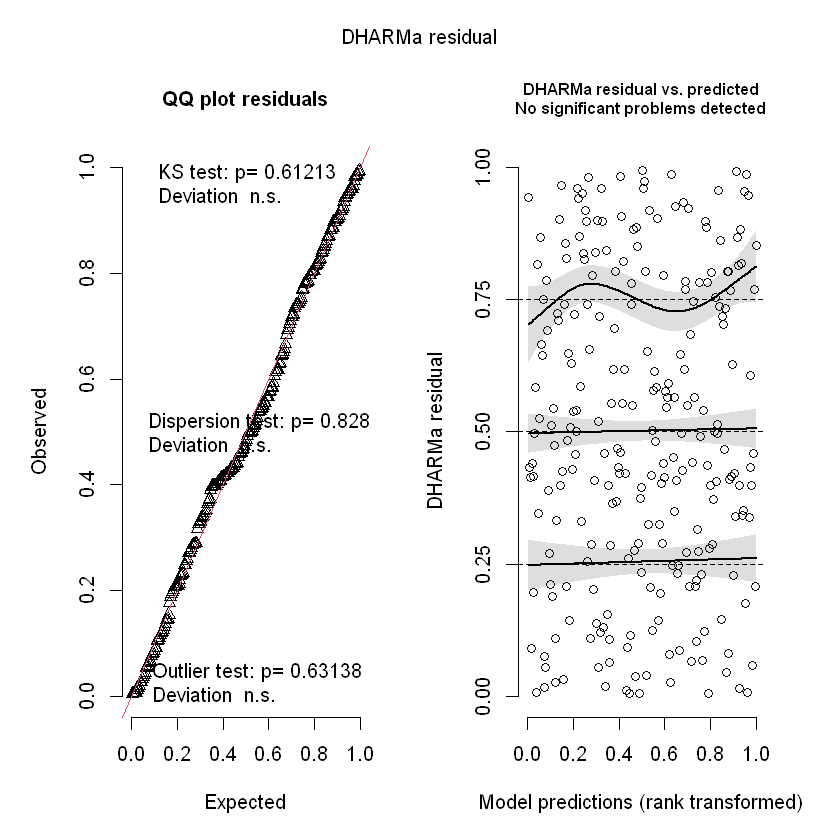

In [5]:
# ── Simulate Tweedie data: biomass (many zeros, continuous positives) ──────────
tweedie_data <- tibble(
  depth  = runif(n, 0, 50),
  # True relationship: peaks at intermediate depth
  mu     = exp(2 - 0.003 * (depth - 25)^2),
  # Simulate via tweedie package
  biomass = tweedie::rtweedie(n, mu = mu, phi = 2, power = 1.5)
) %>% select(-mu)

cat(sprintf("Zero proportion: %.1f%%\n", mean(tweedie_data$biomass == 0) * 100))

# ── Fit Tweedie GAM ───────────────────────────────────────────────────────────
# tw() estimates the power parameter p automatically
gam_tw <- mgcv::gam(
  biomass ~ s(depth),
  data   = tweedie_data,
  family = mgcv::tw(),   # tw() estimates p; twlss() estimates phi and p as smooths
  method = "REML"
)
summary(gam_tw)
# Estimated p shown in summary output

# ── Plot ──────────────────────────────────────────────────────────────────────
gratia::draw(gam_tw, residuals = TRUE) +
  labs(title = "Tweedie GAM: Biomass vs. Depth",
       subtitle = "Handles zeros + continuous positive values")

# ── DHARMa check ──────────────────────────────────────────────────────────────
sim_tw <- DHARMa::simulateResiduals(gam_tw, n = 500)
plot(sim_tw)

---

## Gamma GAM

For strictly positive, right-skewed continuous data. Common for claim amounts, concentrations, and waiting times where zero is impossible and the distribution is right-skewed.


Family: Gamma 
Link function: log 

Formula:
amount ~ s(risk)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  5.42248    0.04574   118.6   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
          edf Ref.df     F p-value    
s(risk) 2.839  3.533 109.6  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.475   Deviance explained = 60.8%
-REML = 1583.6  Scale est. = 0.52298   n = 250

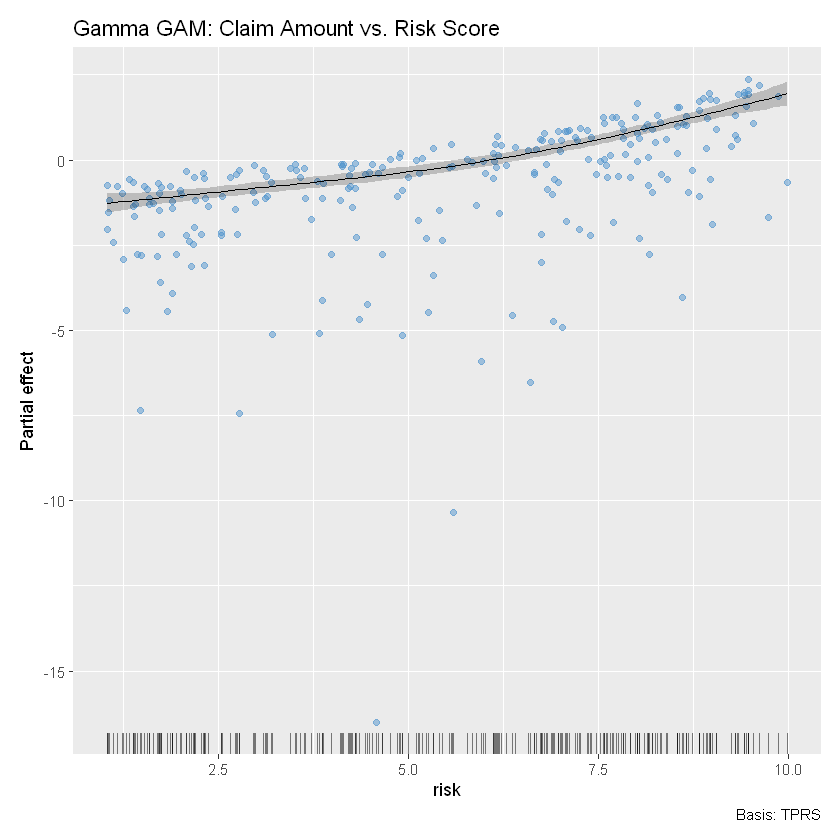

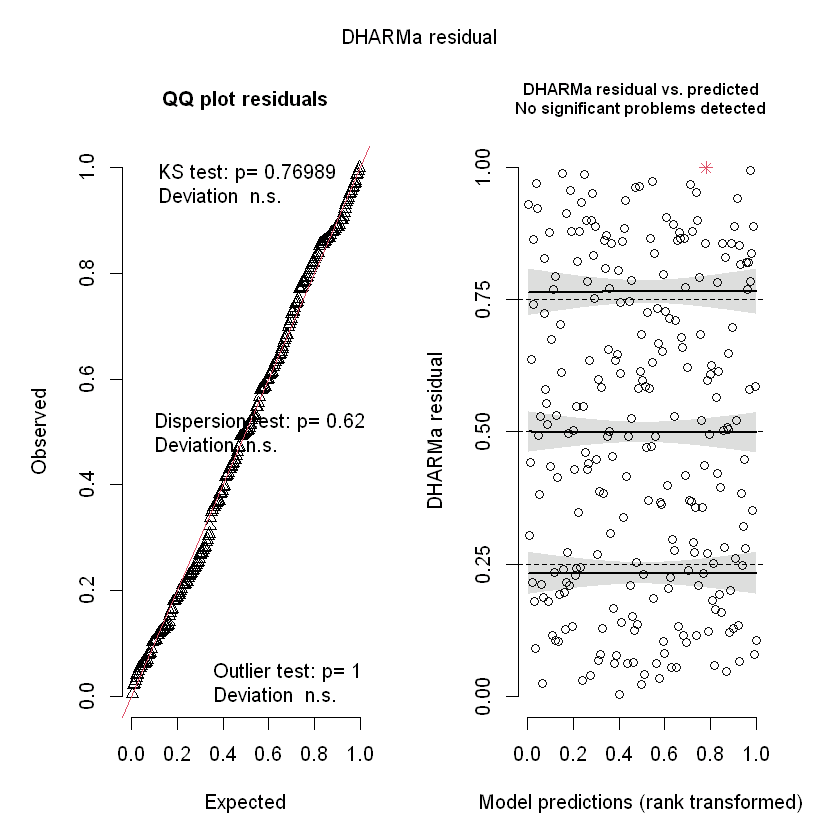

In [6]:
# ── Simulate: claim severity as function of risk score ────────────────────────
gamma_data <- tibble(
  risk   = runif(n, 1, 10),
  mu     = exp(4 + 0.12 * risk + 0.02 * risk^2),
  amount = rgamma(n, shape = 2, rate = 2 / mu)   # E[amount] = mu
) %>% select(-mu)

# ── Fit Gamma GAM ─────────────────────────────────────────────────────────────
gam_gamma <- mgcv::gam(
  amount ~ s(risk),
  data   = gamma_data,
  family = Gamma(link = "log"),
  method = "REML"
)
summary(gam_gamma)
gratia::draw(gam_gamma, residuals = TRUE) +
  labs(title = "Gamma GAM: Claim Amount vs. Risk Score")

# ── DHARMa check ──────────────────────────────────────────────────────────────
sim_gamma <- DHARMa::simulateResiduals(gam_gamma, n = 500)
plot(sim_gamma)

---

## Choosing the Right Family

Use this decision workflow:

In [7]:
# ── Decision checklist ────────────────────────────────────────────────────────
# 1. What type of response do I have?
#    Continuous symmetric           → gaussian
#    Binary (0/1)                   → binomial
#    Proportion (0-1)               → binomial (with cbind or weights)
#    Non-negative integers          → start with poisson
#    Strictly positive continuous   → Gamma
#    Non-negative continuous + zeros → Tweedie or ziP

# 2. For Poisson: check overdispersion with DHARMa
#    Overdispersed → negative binomial (nb())
#    Zero-inflated → ziP or consider hurdle (use glmmTMB for zero-inflated GAMMs)

# 3. For Tweedie: examine proportion of zeros and distribution of positives
#    Many zeros + continuous positives → tw()
#    Only positives → Gamma

# ── Compare families with AIC ─────────────────────────────────────────────────
# Fit competing families to count data and compare
gam_p  <- mgcv::gam(count ~ s(pH), data = nb_data, family = poisson,  method = "REML")
gam_nb2 <- mgcv::gam(count ~ s(pH), data = nb_data, family = mgcv::nb(), method = "REML")
AIC(gam_p, gam_nb2)
# Always pair AIC comparison with DHARMa diagnostics on the preferred model

,df,AIC
,<dbl>,<dbl>
gam_p,8.951659,3840.847
gam_nb2,6.627127,1924.797


---

## Common Pitfalls

**1. Defaulting to Gaussian for non-normal responses**  
Gaussian GAMs fitted to count or binary data produce nonsensical predictions (negative counts, probabilities > 1). Always match the family to the response type.

**2. Using Poisson without checking overdispersion**  
Poisson GAMs are almost always overdispersed for ecological count data. Always fit Poisson first, run DHARMa's `testDispersion()`, then upgrade to NB if needed.

**3. Using Gaussian when Tweedie is needed**  
Zero-inflated continuous data (biomass, rainfall, pure premium) fitted with Gaussian will underpredict the spike at zero and overpredict negatives. Use Tweedie.

**4. Using Gamma when data contain exact zeros**  
Gamma requires strictly positive values. One zero will cause the model to fail or produce unreliable estimates. Use Tweedie for data with zeros.

**5. Not running DHARMa after changing family**  
After selecting a family, always validate with DHARMa simulation-based residuals. A good family choice should produce uniform scaled residuals.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*